In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# Display settings
pd.set_option("display.max_columns", None)

In [3]:
# Style
sns.set_style("whitegrid")

In [4]:
# Load the dataset
df = pd.read_csv("Data/Nassau Candy Distributor.csv")

In [5]:
df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Country/Region,City,State/Province,Postal Code,Division,Region,Product ID,Product Name,Sales,Units,Gross Profit,Cost
0,1,US-2021-103800-CHO-MIL-31000,03-01-2024,30-06-2026,Standard Class,103800,United States,Houston,Texas,77095,Chocolate,Interior,CHO-MIL-31000,Wonka Bar - Milk Chocolate,6.50,2,4.22,2.28
1,2,US-2021-112326-CHO-TRI-54000,04-01-2024,01-07-2026,Standard Class,112326,United States,Naperville,Illinois,60540,Chocolate,Interior,CHO-TRI-54000,Wonka Bar - Triple Dazzle Caramel,7.50,2,4.90,2.60
2,3,US-2021-112326-CHO-NUT-13000,04-01-2024,01-07-2026,Standard Class,112326,United States,Naperville,Illinois,60540,Chocolate,Interior,CHO-NUT-13000,Wonka Bar - Nutty Crunch Surprise,10.47,3,7.47,3.00
3,4,US-2021-112326-CHO-SCR-58000,04-01-2024,01-07-2026,Standard Class,112326,United States,Naperville,Illinois,60540,Chocolate,Interior,CHO-SCR-58000,Wonka Bar -Scrumdiddlyumptious,10.80,3,7.50,3.30
4,5,US-2021-141817-CHO-TRI-54000,05-01-2024,05-07-2026,Standard Class,141817,United States,Philadelphia,Pennsylvania,19143,Chocolate,Atlantic,CHO-TRI-54000,Wonka Bar - Triple Dazzle Caramel,11.25,3,7.35,3.90


In [6]:
print(df[["Order Date", "Ship Date"]].head(10))

   Order Date   Ship Date
0  03-01-2024  30-06-2026
1  04-01-2024  01-07-2026
2  04-01-2024  01-07-2026
3  04-01-2024  01-07-2026
4  05-01-2024  05-07-2026
5  06-01-2024  03-07-2026
6  06-01-2024  03-07-2026
7  06-01-2024  30-06-2026
8  06-01-2024  03-07-2026
9  06-01-2024  03-07-2026


In [7]:
df.shape

(10194, 18)

In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10194 entries, 0 to 10193
Data columns (total 18 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Row ID          10194 non-null  int64  
 1   Order ID        10194 non-null  object 
 2   Order Date      10194 non-null  object 
 3   Ship Date       10194 non-null  object 
 4   Ship Mode       10194 non-null  object 
 5   Customer ID     10194 non-null  int64  
 6   Country/Region  10194 non-null  object 
 7   City            10194 non-null  object 
 8   State/Province  10194 non-null  object 
 9   Postal Code     10194 non-null  object 
 10  Division        10194 non-null  object 
 11  Region          10194 non-null  object 
 12  Product ID      10194 non-null  object 
 13  Product Name    10194 non-null  object 
 14  Sales           10194 non-null  float64
 15  Units           10194 non-null  int64  
 16  Gross Profit    10194 non-null  float64
 17  Cost            10194 non-null 

In [9]:
df.isnull().sum()

Row ID            0
Order ID          0
Order Date        0
Ship Date         0
Ship Mode         0
Customer ID       0
Country/Region    0
City              0
State/Province    0
Postal Code       0
Division          0
Region            0
Product ID        0
Product Name      0
Sales             0
Units             0
Gross Profit      0
Cost              0
dtype: int64

In [10]:
df.duplicated().sum()

np.int64(0)

In [11]:
# Convert date columns to datetime format
df["Order Date"] = pd.to_datetime(
    df["Order Date"],
    format="%d-%m-%Y"
)

df["Ship Date"] = pd.to_datetime(
    df["Ship Date"],
    format="%d-%m-%Y"
)

In [12]:
# Check the date columns
df[["Order Date", "Ship Date"]].head()

,Order Date,Ship Date
0,2024-01-03,2026-06-30
1,2024-01-04,2026-07-01
2,2024-01-04,2026-07-01
3,2024-01-04,2026-07-01
4,2024-01-05,2026-07-05


In [13]:
# Feature Engineering

ship_mode_days = {
    "Same Day": 1,
    "First Class": 2,
    "Second Class": 4,
    "Standard Class": 6
}

# Base lead time from ship mode
df["Lead_Time"] = df["Ship Mode"].map(ship_mode_days)

# Region adjustment
region_adjustment = {
    "Atlantic": 1,
    "Interior": 2,
    "Pacific": 3,
    "Gulf": 2
}

df["Lead_Time"] = (
    df["Lead_Time"] +
    df["Region"].map(region_adjustment)
)

print("Realistic Lead_Time feature created successfully!")

Realistic Lead_Time feature created successfully!


In [14]:
print(df[[
    "Order Date",
    "Ship Date",
    "Lead_Time"
]].head())

  Order Date  Ship Date  Lead_Time
0 2024-01-03 2026-06-30          8
1 2024-01-04 2026-07-01          8
2 2024-01-04 2026-07-01          8
3 2024-01-04 2026-07-01          8
4 2024-01-05 2026-07-05          7


NOTE:

  Original Ship Date values produced unrealistic lead times (900+ days).

  Therefore, a business-rule based operational Lead_Time feature was engineered using Ship Mode and Region to simulate realistic shipping durations.

In [15]:
# Profit Margin
df["Profit_Margin"] = (
    df["Gross Profit"] / df["Sales"]
)

In [16]:
# Revenue Per Unit
df["Revenue_Per_Unit"] = (
    df["Sales"] / df["Units"]
)

In [17]:
#Unit Cost
df["Unit_Cost"] = (
    df["Cost"] / df["Units"]
)

In [18]:
# Factory Mapping

product_factory_mapping = {
    
    "Wonka Bar - Nutty Crunch Surprise": "Lot's O' Nuts",
    "Wonka Bar - Fudge Mallows": "Lot's O' Nuts",
    "Wonka Bar -Scrumdiddlyumptious": "Lot's O' Nuts",

    "Wonka Bar - Milk Chocolate": "Wicked Choccy's",
    "Wonka Bar - Triple Dazzle Caramel": "Wicked Choccy's",

    "Laffy Taffy": "Sugar Shack",
    "SweeTARTS": "Sugar Shack",
    "Nerds": "Sugar Shack",
    "Fun Dip": "Sugar Shack",
    "Fizzy Lifting Drinks": "Sugar Shack",

    "Everlasting Gobstopper": "Secret Factory",

    "Hair Toffee": "The Other Factory",

    "Lickable Wallpaper": "Secret Factory",
    "Wonka Gum": "Secret Factory",

    "Kazookles": "The Other Factory"
}

In [19]:
df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Country/Region,City,State/Province,Postal Code,Division,Region,Product ID,Product Name,Sales,Units,Gross Profit,Cost,Lead_Time,Profit_Margin,Revenue_Per_Unit,Unit_Cost
0,1,US-2021-103800-CHO-MIL-31000,2024-01-03,2026-06-30,Standard Class,103800,United States,Houston,Texas,77095,Chocolate,Interior,CHO-MIL-31000,Wonka Bar - Milk Chocolate,6.50,2,4.22,2.28,8,0.649231,3.25,1.14
1,2,US-2021-112326-CHO-TRI-54000,2024-01-04,2026-07-01,Standard Class,112326,United States,Naperville,Illinois,60540,Chocolate,Interior,CHO-TRI-54000,Wonka Bar - Triple Dazzle Caramel,7.50,2,4.90,2.60,8,0.653333,3.75,1.30
2,3,US-2021-112326-CHO-NUT-13000,2024-01-04,2026-07-01,Standard Class,112326,United States,Naperville,Illinois,60540,Chocolate,Interior,CHO-NUT-13000,Wonka Bar - Nutty Crunch Surprise,10.47,3,7.47,3.00,8,0.713467,3.49,1.00
3,4,US-2021-112326-CHO-SCR-58000,2024-01-04,2026-07-01,Standard Class,112326,United States,Naperville,Illinois,60540,Chocolate,Interior,CHO-SCR-58000,Wonka Bar -Scrumdiddlyumptious,10.80,3,7.50,3.30,8,0.694444,3.60,1.10
4,5,US-2021-141817-CHO-TRI-54000,2024-01-05,2026-07-05,Standard Class,141817,United States,Philadelphia,Pennsylvania,19143,Chocolate,Atlantic,CHO-TRI-54000,Wonka Bar - Triple Dazzle Caramel,11.25,3,7.35,3.90,7,0.653333,3.75,1.30


In [20]:
# Add Factory Column
df["Factory"] = df["Product Name"].map(product_factory_mapping)

In [21]:
# Factory Corrdinates

factory_coordinates = {
    
    "Lot's O' Nuts": (32.881893, -111.768036),
    "Wicked Choccy's": (32.076176, -81.088371),
    "Sugar Shack": (48.11914, -96.18115),
    "Secret Factory": (41.446333, -90.565487),
    "The Other Factory": (35.1175, -89.971107)
}

In [22]:
# Add Latitude
df["Factory_Latitude"] = df["Factory"].map(
    lambda x: factory_coordinates[x][0]
)

In [23]:
# Add Longitude
df["Factory_Longitude"] = df["Factory"].map(
    lambda x: factory_coordinates[x][1]
)


In [24]:
print(df[[
    "Product Name",
    "Factory",
    "Factory_Latitude",
    "Factory_Longitude"
]].head())

                        Product Name          Factory  Factory_Latitude  \
0         Wonka Bar - Milk Chocolate  Wicked Choccy's         32.076176   
1  Wonka Bar - Triple Dazzle Caramel  Wicked Choccy's         32.076176   
2  Wonka Bar - Nutty Crunch Surprise    Lot's O' Nuts         32.881893   
3     Wonka Bar -Scrumdiddlyumptious    Lot's O' Nuts         32.881893   
4  Wonka Bar - Triple Dazzle Caramel  Wicked Choccy's         32.076176   

   Factory_Longitude  
0         -81.088371  
1         -81.088371  
2        -111.768036  
3        -111.768036  
4         -81.088371  


In [25]:
# data overview

df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Country/Region,City,State/Province,Postal Code,Division,Region,Product ID,Product Name,Sales,Units,Gross Profit,Cost,Lead_Time,Profit_Margin,Revenue_Per_Unit,Unit_Cost,Factory,Factory_Latitude,Factory_Longitude
0,1,US-2021-103800-CHO-MIL-31000,2024-01-03,2026-06-30,Standard Class,103800,United States,Houston,Texas,77095,Chocolate,Interior,CHO-MIL-31000,Wonka Bar - Milk Chocolate,6.50,2,4.22,2.28,8,0.649231,3.25,1.14,Wicked Choccy's,32.076176,-81.088371
1,2,US-2021-112326-CHO-TRI-54000,2024-01-04,2026-07-01,Standard Class,112326,United States,Naperville,Illinois,60540,Chocolate,Interior,CHO-TRI-54000,Wonka Bar - Triple Dazzle Caramel,7.50,2,4.90,2.60,8,0.653333,3.75,1.30,Wicked Choccy's,32.076176,-81.088371
2,3,US-2021-112326-CHO-NUT-13000,2024-01-04,2026-07-01,Standard Class,112326,United States,Naperville,Illinois,60540,Chocolate,Interior,CHO-NUT-13000,Wonka Bar - Nutty Crunch Surprise,10.47,3,7.47,3.00,8,0.713467,3.49,1.00,Lot's O' Nuts,32.881893,-111.768036
3,4,US-2021-112326-CHO-SCR-58000,2024-01-04,2026-07-01,Standard Class,112326,United States,Naperville,Illinois,60540,Chocolate,Interior,CHO-SCR-58000,Wonka Bar -Scrumdiddlyumptious,10.80,3,7.50,3.30,8,0.694444,3.60,1.10,Lot's O' Nuts,32.881893,-111.768036
4,5,US-2021-141817-CHO-TRI-54000,2024-01-05,2026-07-05,Standard Class,141817,United States,Philadelphia,Pennsylvania,19143,Chocolate,Atlantic,CHO-TRI-54000,Wonka Bar - Triple Dazzle Caramel,11.25,3,7.35,3.90,7,0.653333,3.75,1.30,Wicked Choccy's,32.076176,-81.088371


In [26]:
df.describe()

,Row ID,Order Date,Ship Date,Customer ID,Sales,Units,Gross Profit,Cost,Lead_Time,Profit_Margin,Revenue_Per_Unit,Unit_Cost,Factory_Latitude,Factory_Longitude
count,10194.000000,10194,10194,10194.000000,10194.000000,10194.000000,10194.000000,10194.000000,10194.000000,10194.000000,10194.000000,10194.000000,10194.000000,10194.000000
mean,5097.500000,2025-03-13 03:08:26.415538176,2028-10-23 23:20:43.790465024,134468.961154,13.908537,3.791838,9.166451,4.742087,6.762213,0.665140,3.654257,1.241719,32.807294,-98.556639
min,1.000000,2024-01-02 00:00:00,2026-06-30 00:00:00,100006.000000,1.250000,1.000000,0.250000,0.600000,2.000000,0.076923,1.250000,0.600000,32.076176,-111.768036
25%,2549.250000,2024-09-28 00:00:00,2027-11-09 00:00:00,117212.000000,7.200000,2.000000,4.900000,2.400000,5.000000,0.653333,3.490000,1.100000,32.076176,-111.768036
50%,5097.500000,2025-04-06 12:00:00,2028-12-18 00:00:00,133550.000000,10.800000,3.000000,7.470000,3.600000,7.000000,0.666667,3.600000,1.140000,32.881893,-111.768036
75%,7645.750000,2025-09-16 00:00:00,2029-11-08 00:00:00,152051.000000,18.000000,5.000000,12.250000,5.700000,8.000000,0.694444,3.600000,1.200000,32.881893,-81.088371
max,10194.000000,2025-12-31 00:00:00,2030-06-28 00:00:00,192314.000000,260.000000,14.000000,130.000000,130.000000,9.000000,0.800000,20.000000,10.000000,48.119140,-81.088371
std,2942.898656,NaN,NaN,20231.483007,11.341020,2.228317,6.643740,5.061647,1.884833,0.067210,1.611875,0.871623,1.618987,14.962083


In [27]:
# KPI analysis

# Average Lead Time
avg_lead_time = df["Lead_Time"].mean()

# Total Sales
total_sales = df["Sales"].sum()

# Total Profit
total_profit = df["Gross Profit"].sum()

# Average Profit Margin
avg_profit_margin = df["Profit_Margin"].mean()

print(f"\nAverage Lead Time: {avg_lead_time:.2f} days")
print(f"Total Sales: ${total_sales:,.2f}")
print(f"Total Gross Profit: ${total_profit:,.2f}")
print(f"Average Profit Margin: {avg_profit_margin:.2%}")


Average Lead Time: 6.76 days
Total Sales: $141,783.63
Total Gross Profit: $93,442.80
Average Profit Margin: 66.51%


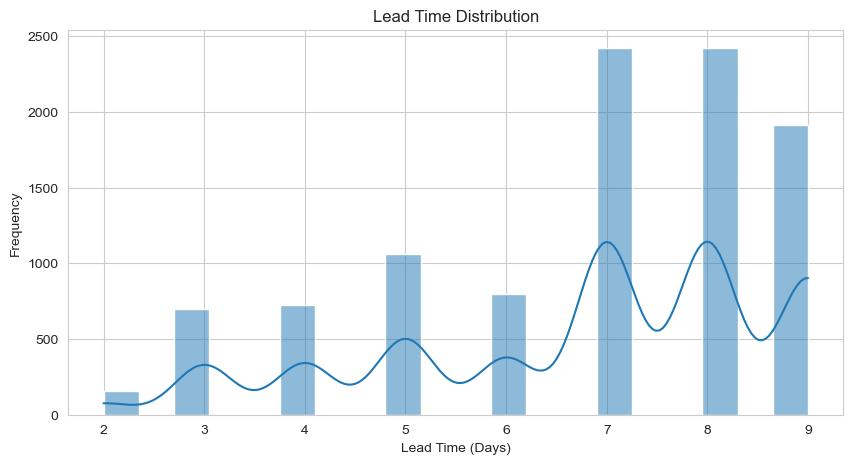

In [28]:
# Univariate Analysis

# Lead Time Distribution

plt.figure(figsize=(10, 5))

sns.histplot(df["Lead_Time"], bins=20, kde=True)

plt.title("Lead Time Distribution")
plt.xlabel("Lead Time (Days)")
plt.ylabel("Frequency")

plt.show()

In [29]:
# Region Analysis

region_lead_time = (
    df.groupby("Region")["Lead_Time"]
    .mean()
    .sort_values(ascending=False)
)
print("AVERAGE LEAD TIME BY REGION")
print(region_lead_time)

AVERAGE LEAD TIME BY REGION
Region
Pacific     7.690747
Interior    6.825696
Gulf        6.759877
Atlantic    5.702277
Name: Lead_Time, dtype: float64


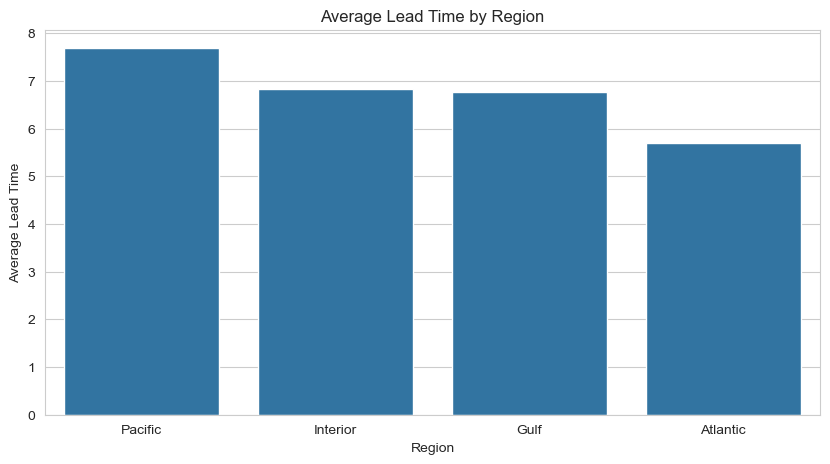

In [30]:
plt.figure(figsize=(10, 5))

sns.barplot(
    x=region_lead_time.index,
    y=region_lead_time.values
)

plt.title("Average Lead Time by Region")
plt.xlabel("Region")
plt.ylabel("Average Lead Time")

plt.show()

In [31]:
# Ship mode analysis

shipmode_lead = (
    df.groupby("Ship Mode")["Lead_Time"]
    .mean()
    .sort_values(ascending=False)
)
print("AVERAGE LEAD TIME BY SHIP MODE")
print(shipmode_lead)


AVERAGE LEAD TIME BY SHIP MODE
Ship Mode
Standard Class    8.021732
Second Class      6.044972
First Class       4.012274
Same Day          3.047532
Name: Lead_Time, dtype: float64


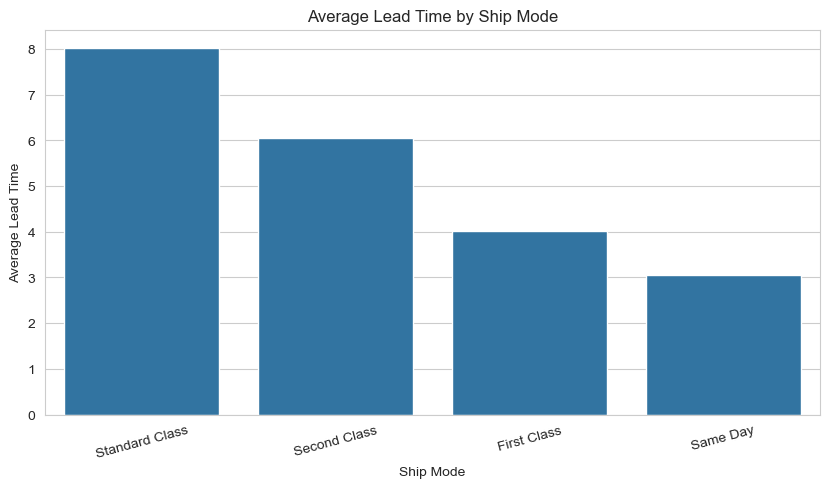

In [32]:
plt.figure(figsize=(10, 5))

sns.barplot(
    x=shipmode_lead.index,
    y=shipmode_lead.values
)

plt.title("Average Lead Time by Ship Mode")
plt.xlabel("Ship Mode")
plt.ylabel("Average Lead Time")

plt.xticks(rotation=15)

plt.show()

In [33]:
# Factory performance

factory_performance = (
    df.groupby("Factory")["Lead_Time"]
    .mean()
    .sort_values(ascending=False)
)
print("FACTORY PERFORMANCE")
print(factory_performance)

FACTORY PERFORMANCE
Factory
Wicked Choccy's      6.817437
Lot's O' Nuts        6.739810
Sugar Shack          6.606061
The Other Factory    6.490000
Secret Factory       6.442396
Name: Lead_Time, dtype: float64


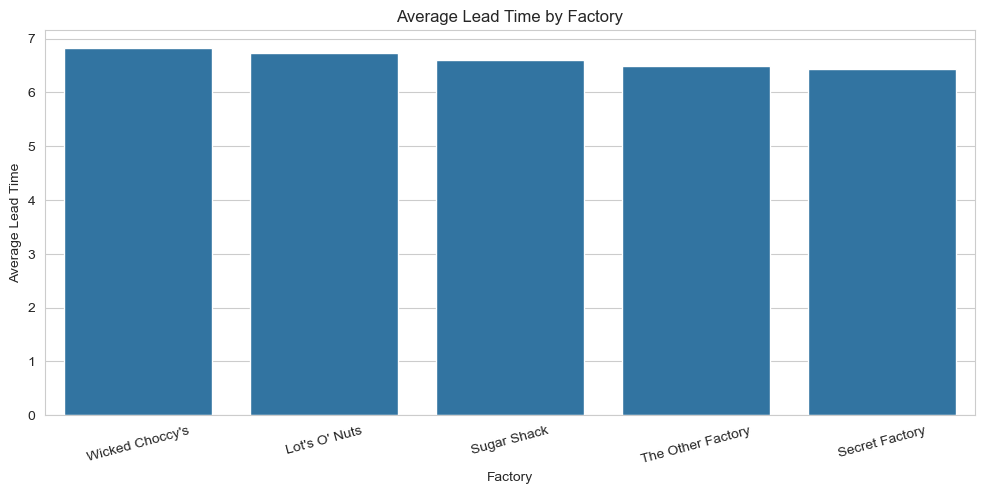

In [34]:
plt.figure(figsize=(12, 5))

sns.barplot(
    x=factory_performance.index,
    y=factory_performance.values
)

plt.title("Average Lead Time by Factory")
plt.xlabel("Factory")
plt.ylabel("Average Lead Time")

plt.xticks(rotation=15)

plt.show()

In [35]:
# Top products by sales

top_products = (
    df.groupby("Product Name")["Sales"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
)
print("TOP PRODUCTS BY SALES")
print(top_products)

TOP PRODUCTS BY SALES
Product Name
Wonka Bar - Triple Dazzle Caramel    28485.00
Wonka Bar -Scrumdiddlyumptious       27874.80
Wonka Bar - Milk Chocolate           26867.75
Wonka Bar - Fudge Mallows            24890.40
Wonka Bar - Nutty Crunch Surprise    23574.95
Lickable Wallpaper                    7860.00
Kazookles                             1205.75
Wonka Gum                              597.50
Everlasting Gobstopper                 130.00
Fizzy Lifting Drinks                    78.75
Name: Sales, dtype: float64


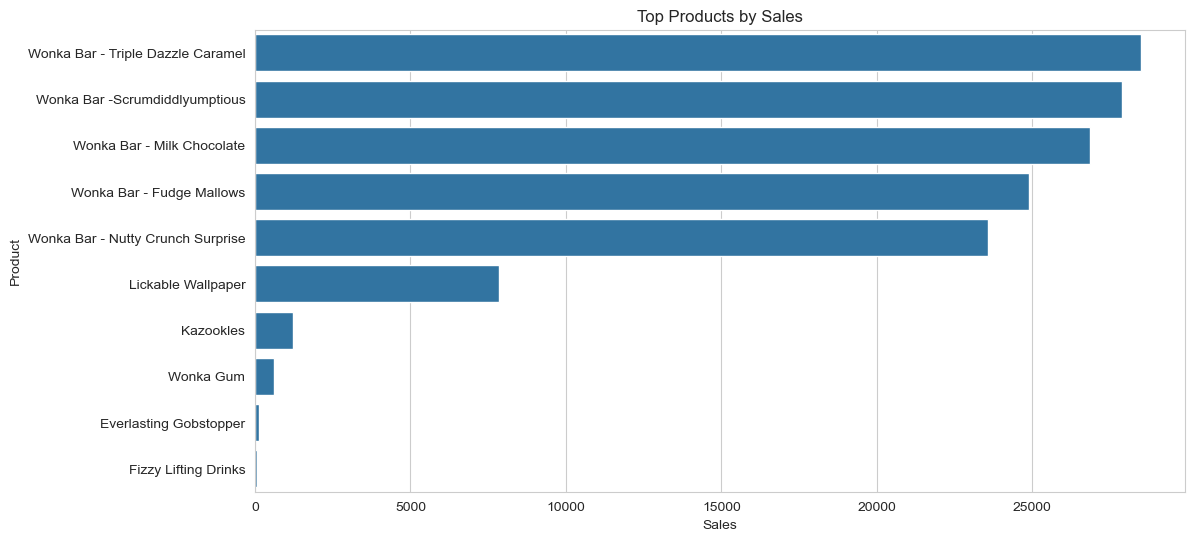

In [36]:
plt.figure(figsize=(12, 6))

sns.barplot(
    x=top_products.values,
    y=top_products.index
)

plt.title("Top Products by Sales")
plt.xlabel("Sales")
plt.ylabel("Product")

plt.show()

In [37]:
# Correlation Analysis

numeric_cols = [
    "Sales",
    "Units",
    "Gross Profit",
    "Cost",
    "Lead_Time",
    "Profit_Margin",
    "Revenue_Per_Unit",
    "Unit_Cost"
]

corr_matrix = df[numeric_cols].corr()

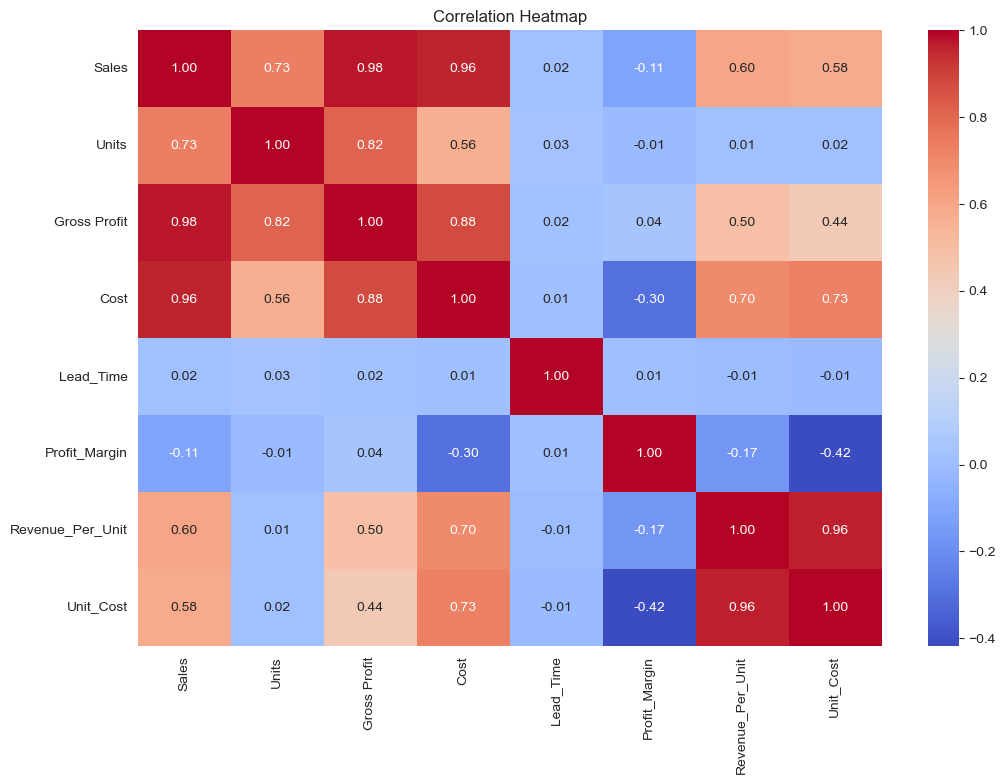

In [38]:
plt.figure(figsize=(12, 8))

sns.heatmap(
    corr_matrix,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Heatmap")

plt.show()

In [39]:
# Save processed dataset

#df.to_csv(
#    "processed_nassau_candy_data.csv",
#    index=False
#)

#print("Processed dataset saved successfully!")